# Self-study try-it activity 4.1: Identifying the Python functions used to calculate MLE

In [1]:
#Importing the necessary libraries

import numpy as np
from scipy.stats import bernoulli
from scipy.stats import binom
import random
import math
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]



## MLE and coin flips

### Question 1: How can you simulate 100 flips of a loaded coin that shows 'H' with a probability of θ = 0.6? What are the different ways of doing so?

**A1.1:** HINTS:

-The coin can be uniformly flipped for 100 times and with a probability of flip of 0.6 and the mean value of 'H' can be counted.

-bernoulli.rvs() can be used. Explore this method and use it for different sets of experiments.

**Answer 1.2**: Simplifying the code above, you will get the following results.

**Answer 1.3**: You can even simplify the code into a single line. Almost all statistical functions in Python scale with a parameter.

In [3]:
### Enter your code import numpy as np
from scipy.stats import bernoulli
np.random.seed(0)
theta = 0.6 #probability of heads
n = 100 #number of patients in the trial
sample = bernoulli.rvs(theta, size = 100) #take a single sample of 100-patients
print(sample)
estimator = np.mean(sample)
print(r'The true value of theta is', theta, 'and our unbiased estimation is', estimator)

[1 0 0 1 1 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1 0 1 1 1 0 0
 0 0 0 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0
 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1]
The true value of theta is 0.6 and our unbiased estimation is 0.62


### Question 2: How do you explain the fact that the fraction of heads is $\hat{\theta} = 0.69$, while $\theta = 0.6$?

Plot the results to demonstrate the law of large numbers: as the number of coin tosses increases, the estimated value $\hat{\theta}$ converges to the true value $\theta$.

**Answer 2.1**: As the number of flips increases, the estimate $\hat{\theta}$ becomes more accurate; the chances of it being far off from the true value $\theta$ also decrease dramatically.

**Answer 2.2**: Let's analyse whether this is accurate.

In [7]:
np.random.seed(15) #A fixed random seed so that everyone gets the same results
a = bernoulli.rvs(0.6, size = pow(10,6))
print(len(a))
print("The fraction of Heads we see is", round(np.mean(a),4))

1000000
The fraction of Heads we see is 0.5997


In [10]:
#Compute a cumulative sum of the array 'a' and divide each cumulative sum by the corresponding index (ranging from 1 to 1000000)

ratios = np.cumsum(a) / np.arange(1, len(a) + 1)
print("The first 10 ratios are:", ratios[:10])

The first 10 ratios are: [0.         0.5        0.66666667 0.75       0.8        0.83333333
 0.85714286 0.875      0.88888889 0.9       ]


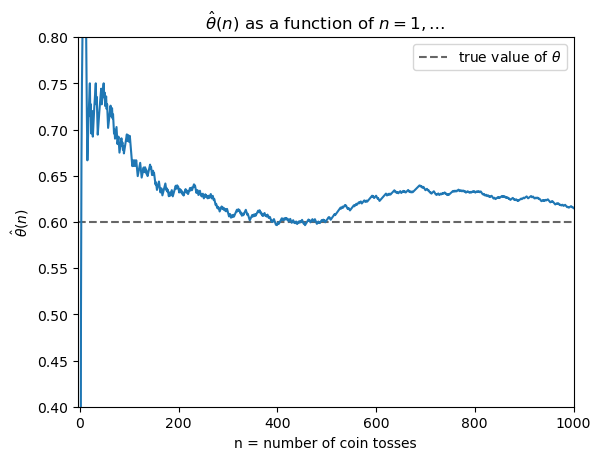

In [15]:
#plot with x-axis given by plot_limit and y-axis of plot_limit.
plot_limit = 1000 #plot how the ratio changes oby increasing $n$
x = np.arange(1, plot_limit + 1)
y = ratios[:plot_limit]
plt.title(r"$\hat{\theta}(n)$ as a function of $n=1,\ldots$")
plt.xlabel("n = number of coin tosses")
plt.ylabel(r"$\hat{\theta}(n)$")
plt.axhline(y = 0.6, color = 'k', linestyle='--', alpha = 0.6, label = r"true value of $\theta$")
plt.plot(x,y)
plt.xlim(-5,plot_limit)
plt.ylim(0.4,0.8)
plt.legend()
plt.show()

### Question 3: If you iterate the same experiment of tossing a loaded coin $100$ times again, say $2,000$ times, do you expect more or less than a $0.69$ fraction of heads each time?

In [20]:
#Repeat the experiment 10 times and print the output. What do you conclude?
np.random.seed(15) #A fixed random seed so that everyone gets the same results
for i in range(10):
    theta = np.mean(bernoulli.rvs(0.6, size = pow(10,6)))
    print(theta)
    print("Experiment #", i+1, ": hat_theta =", theta)


0.599699
Experiment # 1 : hat_theta = 0.599699
0.599876
Experiment # 2 : hat_theta = 0.599876
0.599844
Experiment # 3 : hat_theta = 0.599844
0.600082
Experiment # 4 : hat_theta = 0.600082
0.600269
Experiment # 5 : hat_theta = 0.600269
0.599342
Experiment # 6 : hat_theta = 0.599342
0.600006
Experiment # 7 : hat_theta = 0.600006
0.600181
Experiment # 8 : hat_theta = 0.600181
0.599764
Experiment # 9 : hat_theta = 0.599764
0.60044
Experiment # 10 : hat_theta = 0.60044


### Question 4: Is there a simpler value to sample than a Bernoulli distribution?

**A4:** There is indeed a simpler way. Recall that the number of "H" outcomes in $n$ tosses of a coin is actually a binomial distribution.

 binom.rvs(n, p, size=100)

 where: n = number of trails

 p = probability

 size = number of times the experiment is conducted

In [21]:
#use binom.rvs()
print("I am easily simulating an example of 100 coin tosses and the number of 'H' is:",  binom.rvs(100, 0.6))

I am easily simulating an example of 100 coin tosses and the number of 'H' is: 59


### Question 5: An adversary hands you a sequence of coin tosses, stored in `sequence`. They claim this sequence was generated by flipping a possibly loaded coin $200$ times. You’re told the same coin was used throughout with no switching midway. 

### They also mention a hidden `magic_number`, which is the true value of $\theta$, the probability of getting 'H', but you're not allowed to see it.

### Then, they pose a challenge: 'I will flip the same coin 1,000 times. Each time it lands on "H", you win 60. Each time it lands on "T", you lose 120.' Would you take the bet?

In [22]:
#magic_number generation and sequence based on magic_number.
np.random.seed(85) #A fixed random seed so that everyone gets the same results
magic_number = np.random.uniform(0,1) #Do not print this number
sequence = bernoulli.rvs(magic_number, size = 200)

In [25]:
sum(sequence) / len(sequence)#Print the number of H's in the given sequence?


np.float64(0.69)

Remember that in this programme, you learned that the MLE estimate of the true $\theta$ (i.e. the probability that heads will appear) is actually proportional to the number of heads you see in this sequence. In other words:

In [26]:
#Compute hat_theta. This is the maximum likelihood estimation.
hat_theta = np.mean(sequence)
print("The MAXIMUM LIKELIHOOD, i.e., the best-estimation of the true theta is", hat_theta)

The MAXIMUM LIKELIHOOD, i.e., the best-estimation of the true theta is 0.69


Now that you estimated ```hat_theta```, you simulate what will happen by writing a code:

In [27]:
#Execute this code to check if you have actually made a fortune.
np.random.seed(85)
flips = bernoulli.rvs(hat_theta, size = 1000) #flipping a coin
total_money = np.sum(flips*60 - (1-flips)*120) 
#The formula profit = flips×60 − (1−flips)×120 correctly calculates your profit by awarding $60 for each heads (when flips = 1)
#and subtracting $120 for each tails (when flips = 0), directly applying the game's payoff rules to every simulated coin flip.
print("The total money in $", total_money, "! Nice.")

The total money in $ 3120 ! Nice.


After the simulation, you see that if you take this bet, you will make a profit. However, you are not sure whether this is accurate. You simulate the experiment several more times, and then you take the average.

In [28]:
number_of_simulations = 10000 #You simulate this much
simulations = np.zeros(number_of_simulations)
for sim in range(number_of_simulations):
    flips = bernoulli.rvs(hat_theta, size = 1000) #Flipping a coin
    simulations[sim] = np.sum(flips*60 - (1-flips)*120)
print("Even in multiple simulations, in average you make $", np.mean(simulations), "! Nice.")

Even in multiple simulations, in average you make $ 4203.942 ! Nice.


Did you overdo the simulations? When playing one round of this game, the expected profit is:

$$\begin{align}
\mathbb{E}[\text{profit}] &=  \mathbb{E}[\text{profit} | H]\cdot\theta + \mathbb{E}[\text{profit} | T]\cdot(1 - \theta)  \\
& = 60 \theta - 120 (1 - \theta).
\end{align}$$

But you don't know $\theta$, so the estimation is:

$$\begin{align}
\mathbb{E}[\text{estimated profit}] &= 60 \hat{\theta} - 120 (1 - \hat{\theta}) \\
& = 60 \cdot 0.69 - 120 \cdot 0.31
& = 4.2
\end{align}$$

When you play this game for $1,000$ times, you will make an expected $\$4,200$. So the previous simulation was close to this number, but you did not need to simulate.

Let's try the game now.

In [29]:
np.random.seed(15)
flips = bernoulli.rvs(magic_number, size = 100) #flipping a coin
np.sum(flips*60 - (1-flips)*120)

np.int64(780)

You started making money in the first $100$ rounds. Let's wait until the game is finished.

In [34]:
np.random.seed(15)
flips = bernoulli.rvs(magic_number, size = 1000) #flipping a coin
profit = np.sum(flips*60 - (1-flips)*120)
print(profit)

-5880


In [33]:
print("Overall, our profit is $", profit)
print("This shows we actually lost money.")
# The adversary reveals the true value of $\theta$:
print("The true value of theta, which we estimated as", hat_theta, "is:", round(magic_number,2))

Overall, our profit is $ -5880
This shows we actually lost money.
The true value of theta, which we estimated as 0.69 is: 0.62


Now you realise the reason you lost money: the provided sequence wasn’t truly representative of the underlying probability.

This raises a couple of important questions:

1. What if the adversary gave you a sequence of $1,000,000$ coin tosses? Would you be more or less confident about playing this game?  

2. How would you explain this game when the given sequence has only $1$ coin toss?

3. Please explain why MLE is favourable even in the case above?

In [ ]:
#Fill in yours answers here.